# Homework 3
Mark Evers  
Student ID 810857406  
3/30/2026

In [1]:
!python --version

Python 3.12.12


In [2]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib as plt
import scipy as sp
from sklearn.metrics import rand_score
%matplotlib inline

n_clusters = 3

## EDA


In [4]:
df = pd.read_csv("spiral-dataset.csv", sep="\t", header=None, names=["x", "y", "class"])
df.head()

,x,y,class
0,31.95,7.95,3
1,31.15,7.30,3
2,30.45,6.65,3
3,29.70,6.00,3
4,28.90,5.55,3


In [5]:
df["class"].unique()

array([3, 1, 2])

## 1.2.3.Generate a figure from the given dataset that resembles Figure 1.


<Axes: xlabel='x', ylabel='y'>

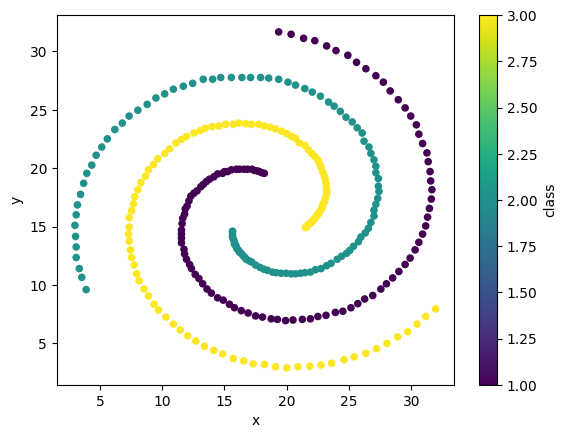

In [6]:
df.plot.scatter(x="x", y="y", c="class", colormap='viridis')

### Implement the k-means clustering algorithm. And do the following:

### • 2.a) Run your k-means algorithm on the given dataset setting the value k=3 (because visually we only have 3 clusters to worry about). And do not forget to randomly initialize the 3 centroids.


In [7]:
# function to generate 3 random centroids within the bounds of the data
def random_centroids():
    # find the bounds of the data (doesn't need to be normalized per the instructions)
    max_x = df["x"].max()
    max_y = df["y"].max()

    # generate `n_clusters` random centroids within the bounds of the data
    centroids = [(np.random.rand() * max_x, np.random.rand() * max_y) for _ in range(n_clusters)]

    # convert to a numpy array and return
    return np.array(centroids)



# function to find the closest centroid for each data point
def find_classes(df, centroids):
    # this is going to be an array of the closest centroid for each data point
    closest_centroids = []

    # build the array of closest centroids
    for index, row in df.iterrows():
        # get an array of the distances from the data point to each centroid
        distances = np.array([sp.spatial.distance.euclidean((row["x"], row["y"]), centroid) for centroid in centroids])
        # find the index of the closest centroid and add it to the list
        best_centroid = np.argmin(distances)
        closest_centroids.append(best_centroid)

    return np.array(closest_centroids)

Now we're going to make a function to iterate:

1. Attach a kmeans_cluster value to each row
2. Use the new dataframe with the kmeans_cluster column to find the mean point for the cluster.
3. Move the centroid to the mean point of each cluster.
4. Repeat until it converges


In [8]:
def do_kmeans(input_df, debug=False):

    # make a copy of the input dataframe to work with
    kmeans_df = input_df.copy()

    # initialize the centroids and assign the initial clusters
    centroids = random_centroids()
    if debug:
        print("Initial centroids:")
        print(f"\t({centroids[0][0]:.2f}, {centroids[0][1]:.2f})")
        print(f"\t({centroids[1][0]:.2f}, {centroids[1][1]:.2f})")
        print(f"\t({centroids[2][0]:.2f}, {centroids[2][1]:.2f})")

    clusters = find_classes(kmeans_df, centroids)

    # initialize some variables to prepare the preconditions for the loop
    old_centroids = [
        (0,0),
        (0,0),
        (0,0)
    ]
    kmeans_df["kmeans_cluster"] = clusters

    # ITERATION: loop until the centroids don't move
    while not np.array_equal(centroids, old_centroids):

        # split the dataframe into three clusters based on the kmeans_cluster column
        cluster1 = kmeans_df[kmeans_df["kmeans_cluster"] == 0]
        cluster2 = kmeans_df[kmeans_df["kmeans_cluster"] == 1]
        cluster3 = kmeans_df[kmeans_df["kmeans_cluster"] == 2]

        # store the old centroids before updating them
        old_centroids = centroids.copy()

        # update the centroids to be the mean of the points in each cluster
        # if a cluster is empty, don't move the centroid
        centroids[0] = (cluster1["x"].mean(), cluster1["y"].mean()) if len(cluster1) > 0 else centroids[0]
        centroids[1] = (cluster2["x"].mean(), cluster2["y"].mean()) if len(cluster2) > 0 else centroids[1]
        centroids[2] = (cluster3["x"].mean(), cluster3["y"].mean()) if len(cluster3) > 0 else centroids[2]

        # print the centroid movement
        if debug:
            if not np.array_equal(centroids[0], old_centroids[0]):
                print(f"Centroid 1 moved from ({old_centroids[0][0]:.2f}, {old_centroids[0][1]:.2f}) to ({centroids[0][0]:.2f}, {centroids[0][1]:.2f})")
            if not np.array_equal(centroids[1], old_centroids[1]):
                print(f"Centroid 2 moved from ({old_centroids[1][0]:.2f}, {old_centroids[1][1]:.2f}) to ({centroids[1][0]:.2f}, {centroids[1][1]:.2f})")
            if not np.array_equal(centroids[2], old_centroids[2]):
                print(f"Centroid 3 moved from ({old_centroids[2][0]:.2f}, {old_centroids[2][1]:.2f}) to ({centroids[2][0]:.2f}, {centroids[2][1]:.2f})")

        # reassign the clusters based on the new centroids
        kmeans_df["kmeans_cluster"] = find_classes(kmeans_df, centroids)
    # END ITERATION
    
    if debug:
        print("Final centroids:")
        print(f"\t({centroids[0][0]:.2f}, {centroids[0][1]:.2f})")
        print(f"\t({centroids[1][0]:.2f}, {centroids[1][1]:.2f})")
        print(f"\t({centroids[2][0]:.2f}, {centroids[2][1]:.2f})")

    # we need to add 1 to the kmeans_cluster column to match the original class labels
    kmeans_df["kmeans_cluster"] = kmeans_df["kmeans_cluster"] + 1

    # return the dataframe with the kmeans_cluster column and the final centroids to be used for the SSE calculation
    return kmeans_df, centroids

In [9]:
kmeans_df, centroids = do_kmeans(df, debug=True)

Initial centroids:
	(13.81, 7.65)
	(10.19, 14.41)
	(14.14, 3.06)
Centroid 1 moved from (13.81, 7.65) to (22.14, 12.04)
Centroid 2 moved from (10.19, 14.41) to (15.73, 20.54)
Centroid 3 moved from (14.14, 3.06) to (21.01, 3.96)
Centroid 1 moved from (22.14, 12.04) to (23.62, 14.42)
Centroid 2 moved from (15.73, 20.54) to (14.56, 20.83)
Centroid 3 moved from (21.01, 3.96) to (18.80, 5.86)
Centroid 1 moved from (23.62, 14.42) to (25.75, 16.41)
Centroid 2 moved from (14.56, 20.83) to (13.49, 20.63)
Centroid 3 moved from (18.80, 5.86) to (17.19, 7.80)
Centroid 1 moved from (25.75, 16.41) to (25.94, 17.62)
Centroid 2 moved from (13.49, 20.63) to (12.71, 21.04)
Centroid 3 moved from (17.19, 7.80) to (16.73, 8.83)
Centroid 1 moved from (25.94, 17.62) to (25.80, 18.19)
Centroid 2 moved from (12.71, 21.04) to (12.30, 21.09)
Centroid 3 moved from (16.73, 8.83) to (16.77, 9.08)
Centroid 1 moved from (25.80, 18.19) to (25.67, 18.61)
Centroid 2 moved from (12.30, 21.09) to (12.05, 20.92)
Centroid 3 

## • 2.b) Once your k-means algorithm has converged above, stop and from your clustering result compute the intrinsic performance metric: Sum of Squared Error, SSE (smaller the better), and the extrinsic performance metric: Rand-Index, RI (higher the better).


Let's find SSE first


In [10]:
def kmeans_sse(df, centroids):
    # our running total
    total = 0

    # iterate through each row
    for index, row in df.iterrows():
        # select the centroid for the cluster that the row belongs to based on the column we added to the dataframe
        centroid = centroids[int(row["kmeans_cluster"] - 1)]
        # the error is the distance from the data point to the centroid
        error = sp.spatial.distance.euclidean((row["x"], row["y"]), centroid)
        # add the squared error to the total
        total += error ** 2

    return total

In [11]:
sse = kmeans_sse(kmeans_df, centroids)
print(f"SSE: {sse}")
ri = rand_score(kmeans_df["class"], kmeans_df["kmeans_cluster"])
print(f"Rand Index: {ri}")

SSE: 12313.275106261695
Rand Index: 0.5542913677961909


## • 2.c) Repeat Task (2.a) & (2.b) another 9 (nine) times randomizing again the initial centroids,and report out of the 10 runs of k-means what is the best SSE & RI you could get.


In [12]:
# some lists to hold our results, initialize with the results from the first attempt
kmeans_df_list = [kmeans_df]
centroids_list = [centroids]
sse_list = [sse]
ri_list = [ri]

# re-print this because I have OCD
print(f"Attempt 01 -> SSE: {sse:.10f}, Rand Index: {ri:.10f}")

# loop 9 times
for class_value in range(9):
    # get the results for this attempt
    this_df, this_centroids = do_kmeans(df)
    this_sse = kmeans_sse(this_df, this_centroids)
    this_ri = rand_score(this_df["class"], this_df["kmeans_cluster"])

    # print the results for this attempt
    print(f"Attempt {class_value+2:02d} -> SSE: {this_sse:.10f}, Rand Index: {this_ri:.10f}")
    
    # append the results to the lists
    kmeans_df_list.append(this_df)
    centroids_list.append(this_centroids)
    sse_list.append(this_sse)
    ri_list.append(this_ri)

# find the best one
best_sse_i = np.argmin(sse_list)
best_ri_i = np.argmax(ri_list)
print(f"\nBest SSE:        Attempt {best_sse_i+1:02d} with SSE:     {sse_list[best_sse_i]:.10f}")
print(f"Best Rand Index: Attempt {best_ri_i+1:02d} with Rand Index: {ri_list[best_ri_i]:.10f}")

# sanity check
if best_sse_i != best_ri_i:
    print("What??? SSE and Rand Index don't agree on the best attempt?")

Attempt 01 -> SSE: 12313.2751062617, Rand Index: 0.5542913678
Attempt 02 -> SSE: 12313.2751062617, Rand Index: 0.5542913678
Attempt 03 -> SSE: 12313.9001754028, Rand Index: 0.5540440267
Attempt 04 -> SSE: 12313.2751062617, Rand Index: 0.5542913678
Attempt 05 -> SSE: 12288.1751702830, Rand Index: 0.5541883090
Attempt 06 -> SSE: 12313.9001754028, Rand Index: 0.5540440267
Attempt 07 -> SSE: 12313.9001754028, Rand Index: 0.5540440267
Attempt 08 -> SSE: 12313.2751062617, Rand Index: 0.5542913678
Attempt 09 -> SSE: 12287.8032604187, Rand Index: 0.5539615797
Attempt 10 -> SSE: 12313.2751062617, Rand Index: 0.5542913678

Best SSE:        Attempt 09 with SSE:     12287.8032604187
Best Rand Index: Attempt 01 with Rand Index: 0.5542913678
What??? SSE and Rand Index don't agree on the best attempt?


## • 2.d) Please draw the clustering results (like Figure 1).


<Axes: title={'center': 'Best SSE model (Attempt 09)'}, xlabel='x', ylabel='y'>

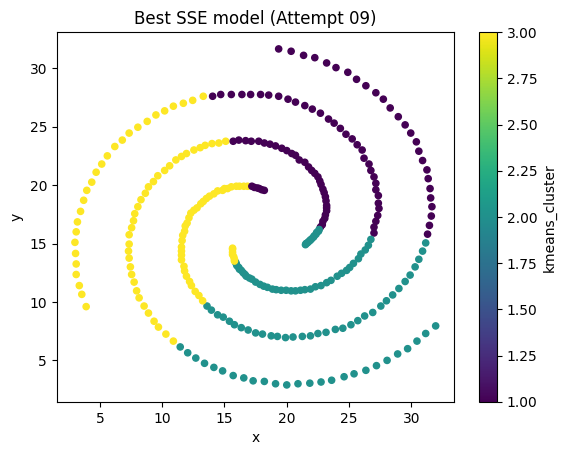

In [13]:
kmeans_df_list[best_sse_i].plot.scatter(x="x", y="y", c="kmeans_cluster", colormap='viridis', title=f"Best SSE model (Attempt {best_sse_i+1:02d})")

<Axes: title={'center': 'Best RI model (Attempt 01)'}, xlabel='x', ylabel='y'>

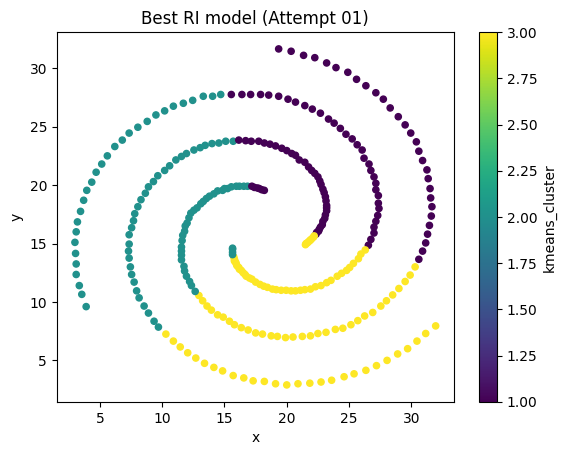

In [14]:
kmeans_df_list[best_ri_i].plot.scatter(x="x", y="y", c="kmeans_cluster", colormap='viridis', title=f"Best RI model (Attempt {best_ri_i+1:02d})")

-
-
-
-
-
-
-
-


## (40 pts) Implement the Hierarchical clustering algorithm. And do the following:
## • 3.a) Using the “single linkage” method, run the hierarchical clustering algorithm on the dataset, and get a 3-cluster result (by cutting the dendrogram at a certain height), and report SSE and RI.

The cell below is my implementation of pairwise distance.  I have deactivated it in favor of scipy's `pdist()` function

In [15]:
import numpy as np
import pandas as pd
import matplotlib as plt
import scipy as sp
from sklearn.metrics import rand_score
%matplotlib inline

Make the point-distance matrix

In [16]:
# reload the data
df = pd.read_csv("spiral-dataset.csv", sep="\t", header=None, names=["x", "y", "class"])

The single linkage algorithm

In [17]:
def single_linkage(df):

    # make a distance matrix and remove the diagonal and lower triangle by setting them to infinity so they are ignored in argmin()
    distance_matrix = sp.spatial.distance.pdist(df[["x", "y"]])
    distance_matrix = sp.spatial.distance.squareform(distance_matrix)
    distance_matrix[np.tril_indices_from(distance_matrix)] = np.inf

    # where we'll save the class values
    single_linkage_classes = np.arange(0, len(distance_matrix))

    # loop until we have 3 clusters
    while len(np.unique(single_linkage_classes)) > 3:

        # find the closest two points
        closest_i = np.argmin(distance_matrix)
        closest_i = np.unravel_index(closest_i, distance_matrix.shape)
        point_one = df.iloc[closest_i[0]][["x", "y"]]
        point_two = df.iloc[closest_i[1]][["x", "y"]]
        # what class are the closest points in?
        point_one_class = single_linkage_classes[closest_i[0]]
        point_two_class = single_linkage_classes[closest_i[1]]

        # collapse the class values of the two closest points into the larger of the two clusters

        # create a mask to match all the current members of each cluster
        x_matches = (single_linkage_classes == point_one_class)
        y_matches = (single_linkage_classes == point_two_class)
        # count how many points are in each cluster
        num_x_matches = x_matches.sum()
        num_y_matches = y_matches.sum()

        # # debugging
        # print(f"Closest points: {point_one['x']}, {point_one['y']} <class {point_one_class}> and {point_two['x']}, {point_two['y']} <class {point_two_class}> with distance {distance_matrix[closest_i]:.4f}")
        # print(f"\tClass {point_one_class} has {num_x_matches} points")
        # print(f"\tClass {point_two_class} has {num_y_matches} points")
        
        # update the distance matrix to reflect the new cluster assignments by taking the minimum distance between points in the two clusters
        # row
        for i in range(distance_matrix.shape[1]):
            if distance_matrix[closest_i[0], i] != np.inf:
                distance_matrix[closest_i[0], i] = min(distance_matrix[closest_i[0], i], distance_matrix[closest_i[1], i])
        # column
        for i in range(distance_matrix.shape[0]):
            if distance_matrix[i, closest_i[1]] != np.inf:
                distance_matrix[i, closest_i[1]] = min(distance_matrix[i, closest_i[0]], distance_matrix[i, closest_i[1]])  
        
        # assign the smaller cluster to the larger cluster
        if num_x_matches >= num_y_matches:
            single_linkage_classes[y_matches] = point_one_class
        elif num_y_matches > num_x_matches:
            single_linkage_classes[x_matches] = point_two_class

        # remove the points so they don't get classified again
        distance_matrix[closest_i[0], :] = np.inf
        distance_matrix[:, closest_i[1]] = np.inf

        print(f"Number of clusters: {len(np.unique(single_linkage_classes))}")

    return single_linkage_classes

Reassign the class values

In [18]:
def class_value_to_original_class(single_linkage_classes, df):

    # count how many points are in each cluster so we can change the class values to be 1, 2, and 3 instead of the original indices
    for class_value in np.unique(single_linkage_classes):
        # create a mask to match all the current members of this cluster and then count them
        mask = (single_linkage_classes == class_value)
        num_class = mask.sum()
        print(f"Class {class_value}: {num_class} points")

        # match the number of points in each cluster to the original class labels to figure out which cluster is which
        for original_class in df["class"].unique():
            if num_class == len(df[df["class"] == original_class]):
                print(f"\tClass {class_value} is original class {original_class}")
                single_linkage_classes[mask] = original_class
                continue

Number of clusters: 311
Number of clusters: 310
Number of clusters: 309
Number of clusters: 308
Number of clusters: 307
Number of clusters: 306
Number of clusters: 305
Number of clusters: 304
Number of clusters: 303
Number of clusters: 302
Number of clusters: 301
Number of clusters: 300
Number of clusters: 299
Number of clusters: 298
Number of clusters: 297
Number of clusters: 296
Number of clusters: 295
Number of clusters: 294
Number of clusters: 293
Number of clusters: 292
Number of clusters: 291
Number of clusters: 290
Number of clusters: 289
Number of clusters: 288
Number of clusters: 287
Number of clusters: 286
Number of clusters: 285
Number of clusters: 284
Number of clusters: 283
Number of clusters: 282
Number of clusters: 281
Number of clusters: 280
Number of clusters: 279
Number of clusters: 278
Number of clusters: 277
Number of clusters: 276
Number of clusters: 275
Number of clusters: 274
Number of clusters: 273
Number of clusters: 272
Number of clusters: 271
Number of cluste

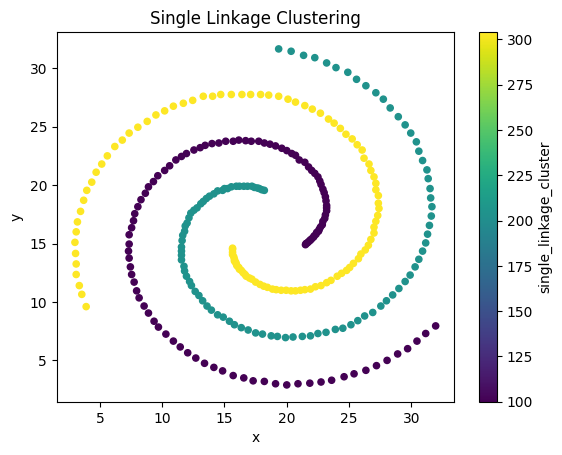

In [27]:
single_linkage_classes = single_linkage(df)
df_single_linkage = df.copy()
df_single_linkage["single_linkage_cluster"] = single_linkage_classes
df_single_linkage.plot.scatter(x="x", y="y", c="single_linkage_cluster", colormap='viridis', title="Single Linkage Clustering")
class_value_to_original_class(single_linkage_classes, df)

In [30]:
# calculate the rand index for single linkage
ri = rand_score(df["class"], single_linkage_classes)
print(f"Single Linkage Rand Index: {ri}")
# calculate the SSE for single linkage
sse = 0
for index, row in df_single_linkage.iterrows():
    # select the centroid for the cluster that the row belongs to based on the column we added to the dataframe
    centroid = df_single_linkage[df_single_linkage["single_linkage_cluster"] == row["single_linkage_cluster"]][["x", "y"]].mean(axis=0).to_numpy()
    # the error is the distance from the data point to the centroid
    error = sp.spatial.distance.euclidean((row["x"], row["y"]), centroid)
    # add the squared error to the total
    sse += error ** 2
print(f"Single Linkage SSE: {sse}")

Single Linkage Rand Index: 1.0
Single Linkage SSE: 30109.35035029312


## • 3.b) Using the “complete linkage” method, run the hierarchical clustering algorithm on the dataset, and get a 3-cluster result (by cutting the dendrogram at a certain height), and report SSE and RI.

In [20]:
def complete_linkage(df):

    # make a distance matrix and remove the diagonal and lower triangle by setting them to infinity so they are ignored in argmin()
    distance_matrix = sp.spatial.distance.pdist(df[["x", "y"]])
    distance_matrix = sp.spatial.distance.squareform(distance_matrix)
    distance_matrix[np.tril_indices_from(distance_matrix)] = np.inf

    # where we'll save the class values
    complete_linkage_classes = np.arange(0, len(distance_matrix))

    # loop until we have 3 clusters
    while len(np.unique(complete_linkage_classes)) > 3:

        # find the closest two points
        closest_i = np.argmin(distance_matrix)
        closest_i = np.unravel_index(closest_i, distance_matrix.shape)
        point_one = df.iloc[closest_i[0]][["x", "y"]]
        point_two = df.iloc[closest_i[1]][["x", "y"]]
        # what class are the closest points in?
        point_one_class = complete_linkage_classes[closest_i[0]]
        point_two_class = complete_linkage_classes[closest_i[1]]

        # collapse the class values of the two closest points into the larger of the two clusters

        # create a mask to match all the current members of each cluster
        x_matches = (complete_linkage_classes == point_one_class)
        y_matches = (complete_linkage_classes == point_two_class)
        # count how many points are in each cluster
        num_x_matches = x_matches.sum()
        num_y_matches = y_matches.sum()

        # # debugging
        # print(f"Closest points: {point_one['x']}, {point_one['y']} <class {point_one_class}> and {point_two['x']}, {point_two['y']} <class {point_two_class}> with distance {distance_matrix[closest_i]:.4f}")
        # print(f"\tClass {point_one_class} has {num_x_matches} points")
        # print(f"\tClass {point_two_class} has {num_y_matches} points")
        
        # assign the smaller cluster to the larger cluster
        if num_x_matches >= num_y_matches:
            complete_linkage_classes[y_matches] = point_one_class
        elif num_y_matches > num_x_matches:
            complete_linkage_classes[x_matches] = point_two_class
        
        # update the distance matrix to reflect the new cluster assignments by taking the maximum distance between points in the two clusters
        # row
        for i in range(distance_matrix.shape[1]):
            if distance_matrix[closest_i[0], i] != np.inf:
                distance_matrix[closest_i[0], i] = max(distance_matrix[closest_i[0], i], distance_matrix[closest_i[1], i])
        # column
        for i in range(distance_matrix.shape[0]):
            if distance_matrix[i, closest_i[1]] != np.inf:
                distance_matrix[i, closest_i[1]] = max(distance_matrix[i, closest_i[0]], distance_matrix[i, closest_i[1]])        
              
        # remove the points so they don't get classified again
        distance_matrix[closest_i[0], :] = np.inf
        distance_matrix[:, closest_i[1]] = np.inf

        print(f"Number of clusters: {len(np.unique(complete_linkage_classes))}")

    return complete_linkage_classes

Number of clusters: 311
Number of clusters: 310
Number of clusters: 309
Number of clusters: 308
Number of clusters: 307
Number of clusters: 306
Number of clusters: 305
Number of clusters: 304
Number of clusters: 303
Number of clusters: 302
Number of clusters: 301
Number of clusters: 300
Number of clusters: 299
Number of clusters: 298
Number of clusters: 297
Number of clusters: 296
Number of clusters: 295
Number of clusters: 294
Number of clusters: 293
Number of clusters: 292
Number of clusters: 291
Number of clusters: 290
Number of clusters: 289
Number of clusters: 288
Number of clusters: 287
Number of clusters: 286
Number of clusters: 285
Number of clusters: 284
Number of clusters: 283
Number of clusters: 282
Number of clusters: 281
Number of clusters: 280
Number of clusters: 279
Number of clusters: 278
Number of clusters: 277
Number of clusters: 276
Number of clusters: 275
Number of clusters: 274
Number of clusters: 273
Number of clusters: 272
Number of clusters: 271
Number of cluste

<Axes: title={'center': 'Complete Linkage Clustering'}, xlabel='x', ylabel='y'>

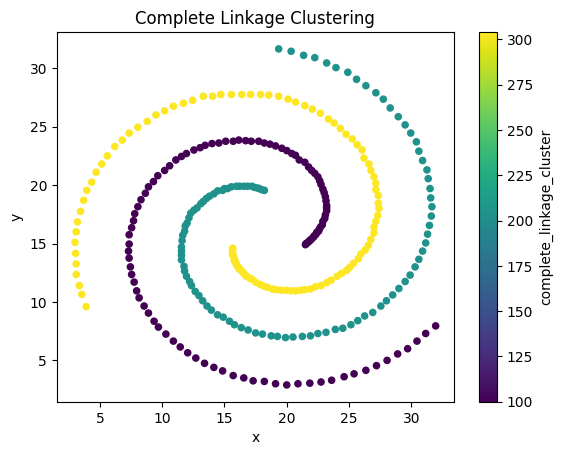

In [21]:
complete_linkage_classes = complete_linkage(df)
df_complete_linkage = df.copy()
df_complete_linkage["complete_linkage_cluster"] = complete_linkage_classes
df_complete_linkage.plot.scatter(x="x", y="y", c="complete_linkage_cluster", colormap='viridis', title="Complete Linkage Clustering")
# class_value_to_original_class(complete_linkage_classes, df)

In [31]:
# calculate the rand index for complete linkage
ri = rand_score(df["class"], complete_linkage_classes)
print(f"Complete Linkage Rand Index: {ri}")
# calculate the SSE for complete linkage
sse = 0
for index, row in df_complete_linkage.iterrows():
    # select the centroid for the cluster that the row belongs to based on the column we added to the dataframe
    centroid = df_complete_linkage[df_complete_linkage["complete_linkage_cluster"] == row["complete_linkage_cluster"]][["x", "y"]].mean(axis=0).to_numpy()
    # the error is the distance from the data point to the centroid
    error = sp.spatial.distance.euclidean((row["x"], row["y"]), centroid)
    # add the squared error to the total
    sse += error ** 2
print(f"Complete Linkage SSE: {sse}")

Complete Linkage Rand Index: 1.0
Complete Linkage SSE: 30109.35035029312


## • 3.c) Using the “average linkage” method, run the hierarchical clustering algorithm on the dataset, and get a 3-cluster result (by cutting the dendrogram at a certain height), and report SSE and RI.

In [22]:
def average_linkage(df):

    # make a distance matrix and remove the diagonal and lower triangle by setting them to infinity so they are ignored in argmin()
    distance_matrix = sp.spatial.distance.pdist(df[["x", "y"]])
    distance_matrix = sp.spatial.distance.squareform(distance_matrix)
    distance_matrix[np.tril_indices_from(distance_matrix)] = np.inf

    # where we'll save the class values
    average_linkage_classes = np.arange(0, len(distance_matrix))

    # loop until we have 3 clusters
    while len(np.unique(average_linkage_classes)) > 3:

        # find the closest two points
        closest_i = np.argmin(distance_matrix)
        closest_i = np.unravel_index(closest_i, distance_matrix.shape)
        point_one = df.iloc[closest_i[0]][["x", "y"]]
        point_two = df.iloc[closest_i[1]][["x", "y"]]
        # what class are the closest points in?
        point_one_class = average_linkage_classes[closest_i[0]]
        point_two_class = average_linkage_classes[closest_i[1]]

        # collapse the class values of the two closest points into the larger of the two clusters

        # create a mask to match all the current members of each cluster
        x_matches = (average_linkage_classes == point_one_class)
        y_matches = (average_linkage_classes == point_two_class)
        # count how many points are in each cluster
        num_x_matches = x_matches.sum()
        num_y_matches = y_matches.sum()

        # # debugging
        # print(f"Closest points: {point_one['x']}, {point_one['y']} <class {point_one_class}> and {point_two['x']}, {point_two['y']} <class {point_two_class}> with distance {distance_matrix[closest_i]:.4f}")
        # print(f"\tClass {point_one_class} has {num_x_matches} points")
        # print(f"\tClass {point_two_class} has {num_y_matches} points")
        
        # assign the smaller cluster to the larger cluster
        new_class = None
        if num_x_matches >= num_y_matches:
            average_linkage_classes[y_matches] = point_one_class
            new_class = point_one_class
        elif num_y_matches > num_x_matches:
            average_linkage_classes[x_matches] = point_two_class
            new_class = point_two_class

        # update the distance matrix to reflect the new cluster assignments by taking the average distance between points in the two clusters
        # row
        for i in range(distance_matrix.shape[1]):

            if distance_matrix[closest_i[0], i] != np.inf:
                # find average distance
                running_total = 0
                for point_a in df[average_linkage_classes == new_class][["x", "y"]].to_numpy():
                    for point_b in df[average_linkage_classes == average_linkage_classes[i]][["x", "y"]].to_numpy():
                        running_total += sp.spatial.distance.euclidean(point_a, point_b)

                average_distance = running_total / (num_x_matches * num_y_matches)
                distance_matrix[closest_i[0], i] = average_distance

        # column
        for i in range(distance_matrix.shape[0]):
            if distance_matrix[i, closest_i[1]] != np.inf:
                # find average distance
                running_total = 0
                for point_a in df[average_linkage_classes == new_class][["x", "y"]].to_numpy():
                    for point_b in df[average_linkage_classes == average_linkage_classes[i]][["x", "y"]].to_numpy():
                        running_total += sp.spatial.distance.euclidean(point_a, point_b)

                average_distance = running_total / (num_x_matches * num_y_matches)
                distance_matrix[i, closest_i[1]] = average_distance
                                    
        # remove the points so they don't get classified again
        distance_matrix[closest_i[0], :] = np.inf
        distance_matrix[:, closest_i[1]] = np.inf

        print(f"Number of clusters: {len(np.unique(average_linkage_classes))}")

    return average_linkage_classes

Number of clusters: 311
Number of clusters: 310
Number of clusters: 309
Number of clusters: 308
Number of clusters: 307
Number of clusters: 306
Number of clusters: 305
Number of clusters: 304
Number of clusters: 303
Number of clusters: 302
Number of clusters: 301
Number of clusters: 300
Number of clusters: 299
Number of clusters: 298
Number of clusters: 297
Number of clusters: 296
Number of clusters: 295
Number of clusters: 294
Number of clusters: 293
Number of clusters: 292
Number of clusters: 291
Number of clusters: 290
Number of clusters: 289
Number of clusters: 288
Number of clusters: 287
Number of clusters: 286
Number of clusters: 285
Number of clusters: 284
Number of clusters: 283
Number of clusters: 282
Number of clusters: 281
Number of clusters: 280
Number of clusters: 279
Number of clusters: 278
Number of clusters: 277
Number of clusters: 276
Number of clusters: 275
Number of clusters: 274
Number of clusters: 273
Number of clusters: 272
Number of clusters: 271
Number of cluste

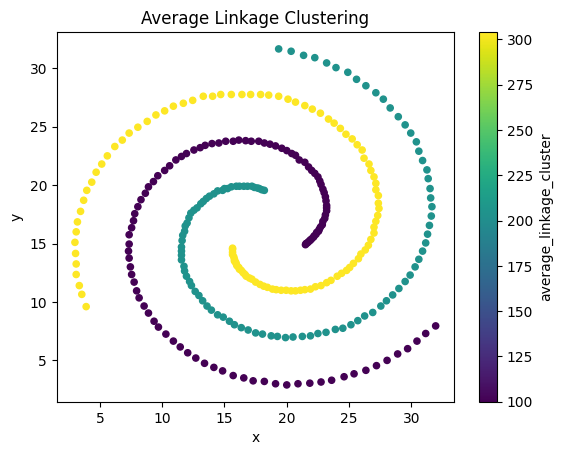

In [32]:
average_linkage_classes = average_linkage(df)
df_average_linkage = df.copy()
df_average_linkage["average_linkage_cluster"] = average_linkage_classes
df_average_linkage.plot.scatter(x="x", y="y", c="average_linkage_cluster", colormap='viridis', title="Average Linkage Clustering")
class_value_to_original_class(average_linkage_classes, df)

In [ ]:
# calculate the rand index for average linkage
ri = rand_score(df["class"], average_linkage_classes)
print(f"Average Linkage Rand Index: {ri}")
# calculate the SSE for average linkage
sse = 0
for index, row in df_average_linkage.iterrows():
    # select the centroid for the cluster that the row belongs to based on the column we added to the dataframe
    centroid = df_average_linkage[df_average_linkage["average_linkage_cluster"] == row["average_linkage_cluster"]][["x", "y"]].mean(axis=0).to_numpy()
    # the error is the distance from the data point to the centroid
    error = sp.spatial.distance.euclidean((row["x"], row["y"]), centroid)
    # add the squared error to the total
    sse += error ** 2
print(f"Average Linkage SSE: {sse}")

Single Linkage Rand Index: 1.0
Single Linkage SSE: 30109.35035029312


## • 3.d) Using the “centroid linkage” method, run the hierarchical clustering algorithm on the dataset, and get a 3-cluster result (by cutting the dendrogram at a certain height), and report SSE and RI.

In [33]:
def centroid_linkage(df):

    # make a distance matrix and remove the diagonal and lower triangle by setting them to infinity so they are ignored in argmin()
    distance_matrix = sp.spatial.distance.pdist(df[["x", "y"]])
    distance_matrix = sp.spatial.distance.squareform(distance_matrix)
    distance_matrix[np.tril_indices_from(distance_matrix)] = np.inf

    # where we'll save the class values
    centroid_linkage_classes = np.arange(0, len(distance_matrix))

    # loop until we have 3 clusters
    while len(np.unique(centroid_linkage_classes)) > 3:

        # find the closest two points
        closest_i = np.argmin(distance_matrix)
        closest_i = np.unravel_index(closest_i, distance_matrix.shape)
        point_one = df.iloc[closest_i[0]][["x", "y"]]
        point_two = df.iloc[closest_i[1]][["x", "y"]]
        # what class are the closest points in?
        point_one_class = centroid_linkage_classes[closest_i[0]]
        point_two_class = centroid_linkage_classes[closest_i[1]]

        # collapse the class values of the two closest points into the larger of the two clusters

        # create a mask to match all the current members of each cluster
        x_matches = (centroid_linkage_classes == point_one_class)
        y_matches = (centroid_linkage_classes == point_two_class)
        # count how many points are in each cluster
        num_x_matches = x_matches.sum()
        num_y_matches = y_matches.sum()

        # # debugging
        # print(f"Closest points: {point_one['x']}, {point_one['y']} <class {point_one_class}> and {point_two['x']}, {point_two['y']} <class {point_two_class}> with distance {distance_matrix[closest_i]:.4f}")
        # print(f"\tClass {point_one_class} has {num_x_matches} points")
        # print(f"\tClass {point_two_class} has {num_y_matches} points")
        
        # assign the smaller cluster to the larger cluster
        new_class = None
        if num_x_matches >= num_y_matches:
            centroid_linkage_classes[y_matches] = point_one_class
            new_class = point_one_class
        elif num_y_matches > num_x_matches:
            centroid_linkage_classes[x_matches] = point_two_class
            new_class = point_two_class

        # update the distance matrix to reflect the new cluster assignments by taking the average distance between points in the two clusters
        # row
        for i in range(distance_matrix.shape[1]):
            if distance_matrix[closest_i[0], i] != np.inf:
                # find the new centroid of the merged cluster
                new_centroid = df[centroid_linkage_classes == new_class][["x", "y"]].mean(axis=0).to_numpy()
                other_centroid = df[centroid_linkage_classes == centroid_linkage_classes[i]][["x", "y"]].mean(axis=0).to_numpy()
                distance_matrix[closest_i[0], i] = sp.spatial.distance.euclidean(new_centroid, other_centroid)

        # column
        for i in range(distance_matrix.shape[0]):
            if distance_matrix[i, closest_i[1]] != np.inf:
                # find the new centroid of the merged cluster
                new_centroid = df[centroid_linkage_classes == new_class][["x", "y"]].mean(axis=0).to_numpy()
                other_centroid = df[centroid_linkage_classes == centroid_linkage_classes[i]][["x", "y"]].mean(axis=0).to_numpy()
                distance_matrix[i, closest_i[1]] = sp.spatial.distance.euclidean(new_centroid, other_centroid)
                                    
        # remove the points so they don't get classified again
        distance_matrix[closest_i[0], :] = np.inf
        distance_matrix[:, closest_i[1]] = np.inf

        print(f"Number of clusters: {len(np.unique(centroid_linkage_classes))}")

    return centroid_linkage_classes

Number of clusters: 311
Number of clusters: 310
Number of clusters: 309
Number of clusters: 308
Number of clusters: 307
Number of clusters: 306
Number of clusters: 305
Number of clusters: 304
Number of clusters: 303
Number of clusters: 302
Number of clusters: 301
Number of clusters: 300
Number of clusters: 299
Number of clusters: 298
Number of clusters: 297
Number of clusters: 296
Number of clusters: 295
Number of clusters: 294
Number of clusters: 293
Number of clusters: 292
Number of clusters: 291
Number of clusters: 290
Number of clusters: 289
Number of clusters: 288
Number of clusters: 287
Number of clusters: 286
Number of clusters: 285
Number of clusters: 284
Number of clusters: 283
Number of clusters: 282
Number of clusters: 281
Number of clusters: 280
Number of clusters: 279
Number of clusters: 278
Number of clusters: 277
Number of clusters: 276
Number of clusters: 275
Number of clusters: 274
Number of clusters: 273
Number of clusters: 272
Number of clusters: 271
Number of cluste

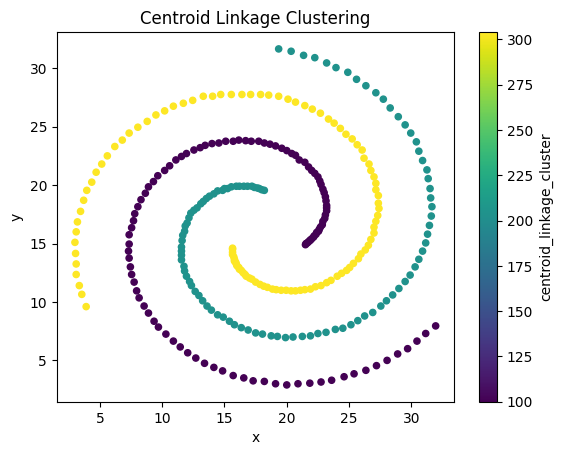

In [34]:
centroid_linkage_classes = centroid_linkage(df)
df_centroid_linkage = df.copy()
df_centroid_linkage["centroid_linkage_cluster"] = centroid_linkage_classes
df_centroid_linkage.plot.scatter(x="x", y="y", c="centroid_linkage_cluster", colormap='viridis', title="Centroid Linkage Clustering")
class_value_to_original_class(centroid_linkage_classes, df)

In [35]:
# calculate the rand index for centroid linkage
ri = rand_score(df["class"], centroid_linkage_classes)
print(f"Centroid Linkage Rand Index: {ri}")
# calculate the SSE for centroid linkage
sse = 0
for index, row in df_centroid_linkage.iterrows():
    # select the centroid for the cluster that the row belongs to based on the column we added to the dataframe
    centroid = df_centroid_linkage[df_centroid_linkage["centroid_linkage_cluster"] == row["centroid_linkage_cluster"]][["x", "y"]].mean(axis=0).to_numpy()
    # the error is the distance from the data point to the centroid
    error = sp.spatial.distance.euclidean((row["x"], row["y"]), centroid)
    # add the squared error to the total
    sse += error ** 2
print(f"Centroid Linkage SSE: {sse}")

Centroid Linkage Rand Index: 1.0
Centroid Linkage SSE: 30109.35035029312


## • 3.e) Please comment, out of the 4 clustering results (3.a), (3.b), (3.c) and (3.d) which method gets you the best SSE as well as RI.

The results for all methods were identical:
```
Rand Index: 1.0
SSE: 30109.35035029312
```

This is a perfect score for each one!

This was surprising at first because I expected them to be clusters in more of circle shapes.  But after thinking about it, it makes sense because the clusters would form in spots at various points along sthe spiral arms.  The the "spots" would link together as the number of clusters grows smaller.

## • 3.f) Please draw the clustering results (like Figure 1).

*The plots of the clustering results can be seen in their respective sections above.*